In [1]:
# import packages
import pandas as pd
import numpy as np
from typing import Union

from sklearn.metrics import mean_squared_error

import pymc as pm
import pymc.sampling.jax as pmjax
import pytensor.tensor as pt
import arviz as az
import arviz_plots as azp

import matplotlib.pyplot as plt
RANDOM_SEED = 457775 # https://www.reddit.com/r/baseball/comments/b5vfik/whos_the_most_random_mlb_player_you_can_think_of/
np.random.seed(RANDOM_SEED)

# for reproducibility
print("pandas: "+pd.__version__)
print("numpy: "+np.__version__)
print("pymc: "+pm.__version__)
import sklearn
print("sklearn: "+sklearn.__version__)
import pytensor
print("pytensor: "+pytensor.__version__)
print("arviz: "+az.__version__)
print("arviz_plots: "+azp.__version__)

pandas: 3.0.1
numpy: 2.4.3
pymc: 5.28.2
sklearn: 1.8.0
pytensor: 2.38.2
arviz: 0.23.4
arviz_plots: 1.0.0


In [2]:
# These are some generic helper functions to help sample for the model
def sample(model: pm.Model, draws: int = 2000, tune: int = 2000, chains: int = 4, target_accept: float = 0.99, random_seed: int = RANDOM_SEED, path:str = 'temp.nc', **kwargs):
    """
    Fit model using MCMC.

    Parameters
    ----------
    model: pm.Model
        PyMC model object.
    draws : int
        Number of draws to keep from the sampling process.
    tune : int
        Number of tuning steps to take before sampling.
    chains : int
        Number of chains to sample.
    target_accept : float
        Target acceptance probability for step size adaptation.
    random_seed : int
        Seed for randomness.
    """
    with model:
        trace = pmjax.sample_numpyro_nuts(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
            random_seed=random_seed,
            idata_kwargs={"log_likelihood": False}
        )
    try:
        az.to_netcdf(trace, path)
    except Exception as e:
        print(f"Error saving trace to {path}: {e}")
    return trace

def compute_log_likelihood(model: pm.Model, trace: az.InferenceData) -> None:
    """Wrapper to compute elemwise log_likelihood of model given InferenceData with posterior group
    Args:
        model (pm.Model): A PyMC model object
        trace (az.InferenceData): Results from sampling
    """
    with model:
        pm.compute_log_likelihood(trace)
    return None

def sample_posterior_pred(model: pm.Model, trace: az.InferenceData) -> az.InferenceData:
    """Generates samples from the posterior predictive distribution for model checks

    Args:
        model (pm.Model): A PyMC model object
        trace (az.InferenceData): Results from sampling

    Returns:
        az.InferenceData: An ArviZ InferenceData object containing the posterior predictive samples.
    """
    with model:
        spp = pm.sample_posterior_predictive(
            trace,
            extend_inferencedata=True,
            random_seed=RANDOM_SEED,
        )
    return spp

In [ ]:
# first use handy index function
def define_index(data: pd.DataFrame, label: str, plus_one:bool=True) -> Union[np.array, dict]:
    """Defines an index variable starting at 1. We add 1 so '0' can act as a placeholder for
    any global optionality
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format

    Returns:
        Union[
            np.array: indexed values
            dict: dictionary mapping the input values and their indexed values
            ]
    """
    unq_ids = data[label].astype(str).unique()
    lookup = {v: i for i, v in enumerate(unq_ids)}
    index_vals = data[label].astype(str).map(lookup).values
    
    if plus_one:
        index_vals = index_vals + 1
    return index_vals, lookup

def map_index(data: pd.DataFrame, label: str, lookup_dict: dict) -> np.array:
    """Applies an index to new values
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format
        lookup_dict (dict): dictionary that contains the mappings from inputs to index

    Returns:
        np.array: indexed values
    """
    data[label] = data[label].apply(str)
    vals = pd.to_numeric(data[label].replace(lookup_dict).values)
    return vals

In [4]:
# import data
df = pd.read_csv('data/bat_speed_model_data.csv')
df['bam_id'] = pd.to_numeric(df['bam_id'], errors='coerce')
df.head()

,bam_id,year,month_name,time_index,player_full_id,full,first,last,bats,birth_date,...,ev90,latent_ev90_mean,latent_ev90_std,swing_total,bat_speed,imputed_bat_speed,imputed_bat_speed_std,model_bat_speed,is_imputed,is_complete
0,405395,2021,Mar/Apr,0,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,106.16,105.744556,0.707558,131.0,NaN,72.313288,1.502616,72.313288,1,0
1,405395,2021,May,1,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,108.40,105.770156,0.676366,107.0,NaN,72.344566,1.488726,72.344566,1,0
2,405395,2021,Jun,2,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,103.90,105.729823,0.658866,92.0,NaN,72.308188,1.492607,72.308188,1,0
3,405395,2021,Jul,3,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,105.79,105.733235,0.646752,106.0,NaN,72.305987,1.483824,72.305987,1,0
4,405395,2021,Aug,4,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,105.56,105.732908,0.647942,54.0,NaN,72.299502,1.487205,72.299502,1,0


In [ ]:
# test data will be all of 2026
testdf = df.loc[df['year']>=2026].reset_index(drop=True)
df = df.loc[df['year']<2026].reset_index(drop=True)

In [ ]:
# standardize age
age_mean = np.mean(df['age'])
age_std = np.std(df['age'])
df['age_z'] = (df['age'] - age_mean)/age_std
age_z = df['age_z'].values

testdf['age_z'] = (testdf['age'] - age_mean)/age_std
df.tail(5)

,bam_id,year,month_name,time_index,player_full_id,full,first,last,bats,birth_date,...,latent_ev90_mean,latent_ev90_std,swing_total,bat_speed,imputed_bat_speed,imputed_bat_speed_std,model_bat_speed,is_imputed,is_complete,age_z
16094,815873,2026,Jun,32,Sean Keys (815873),Sean Keys,Sean,Keys,L,2003-05-26,...,102.989423,2.195548,18.0,75.227778,69.756447,2.461716,75.227778,0,0,-1.513600
16095,815873,2026,Jul,33,Sean Keys (815873),Sean Keys,Sean,Keys,L,2003-05-26,...,102.995081,2.196605,38.0,73.355263,69.730513,2.466510,73.355263,0,0,-1.490937
16096,823550,2026,May,31,Sung-Mun Song (823550),Sung-Mun Song,Sung-Mun,Song,L,1996-08-29,...,103.141045,1.470755,47.0,70.774468,69.872766,1.941269,70.774468,0,0,0.322044
16097,823550,2026,Jun,32,Sung-Mun Song (823550),Sung-Mun Song,Sung-Mun,Song,L,1996-08-29,...,103.167626,1.476328,58.0,70.934483,69.898081,1.957539,70.934483,0,0,0.345462
16098,823550,2026,Jul,33,Sung-Mun Song (823550),Sung-Mun Song,Sung-Mun,Song,L,1996-08-29,...,103.198505,1.495400,29.0,71.875862,69.912583,1.953077,71.875862,0,0,0.368124


In [ ]:
n_obs = len(df)
df['player_full_id'] = df['full'] + " (" + df['bam_id'].astype(str) + ")"
testdf['player_full_id'] = testdf['full'] + " (" + testdf['bam_id'].astype(str) + ")"

In [7]:
df.loc[df['age_z']>=3.5][['player_full_id','model_bat_speed', 'is_imputed', 'latent_ev90_mean', 'ev90', 'bips']]

,player_full_id,model_bat_speed,is_imputed,latent_ev90_mean,ev90,bips
0,Albert Pujols (405395),72.313288,1,105.744556,106.16,63.0
1,Albert Pujols (405395),72.344566,1,105.770156,108.40,41.0
2,Albert Pujols (405395),72.308188,1,105.729823,103.90,41.0
3,Albert Pujols (405395),72.305987,1,105.733235,105.79,44.0
4,Albert Pujols (405395),72.299502,1,105.732908,105.56,19.0
5,Albert Pujols (405395),72.308690,1,105.735999,105.10,24.0
6,Albert Pujols (405395),72.318841,1,105.750262,104.63,24.0
7,Albert Pujols (405395),72.347634,1,105.780984,104.10,41.0
8,Albert Pujols (405395),72.412231,1,105.850108,105.14,29.0
9,Albert Pujols (405395),72.499405,1,105.932932,107.85,44.0


In [8]:
df.loc[df['age_z']<=-2.25][['player_full_id','model_bat_speed', 'is_imputed', 'latent_ev90_mean', 'ev90', 'bips']]

,player_full_id,model_bat_speed,is_imputed,latent_ev90_mean,ev90,bips
13320,Wander Franco (677551),70.749712,1,104.082701,106.56,25.0
13321,Wander Franco (677551),70.745874,1,104.066010,104.00,67.0
15330,Junior Caminero (691406),77.192857,0,108.581494,108.30,26.0
15478,Jackson Chourio (694192),72.146835,0,104.710265,102.34,64.0
15479,Jackson Chourio (694192),73.594872,0,104.822028,103.90,51.0
15480,Jackson Chourio (694192),71.895489,0,104.962983,103.01,60.0
15481,Jackson Chourio (694192),72.010687,0,105.170761,106.70,70.0
15917,Jackson Holliday (702616),71.414286,0,103.458967,101.50,16.0
15956,Konnor Griffin (804606),74.406630,0,106.021388,106.00,61.0
15957,Konnor Griffin (804606),74.709694,0,106.053912,105.71,72.0


In [ ]:
df["player_idx"], player_lookup = define_index(df, "player_full_id", plus_one=False)
player_idx_vals = df['player_idx'].values.astype("int32")
player_name_list = list(player_lookup.keys())

testdf['player_idx'] = map_index(testdf, "player_full_id", player_lookup)


df['month_idx'], month_lookup = define_index(df, 'month_name', plus_one=False)
month_idx_vals = df['month_idx'].values.astype("int32")
month_name_list = list(month_lookup.keys())

testdf['month_idx'] = map_index(testdf, "month_name", month_lookup)
testdf

First model to check is one with a quadratic aging curve

In [10]:
bat_speed_target = df['model_bat_speed'].values
swings_sqrt_values = np.sqrt(df['swing_total'].values)

# define emprical prior for bat speed
prior_mean = np.mean(bat_speed_target)
prior_std = np.std(bat_speed_target)
print(prior_mean)
print(prior_std)

# define age and age squared for the quadratic model
age_values = df['age_z'].values
age_sq_values = age_values**2

70.31885615004146
2.671300574022194


<Axes: >

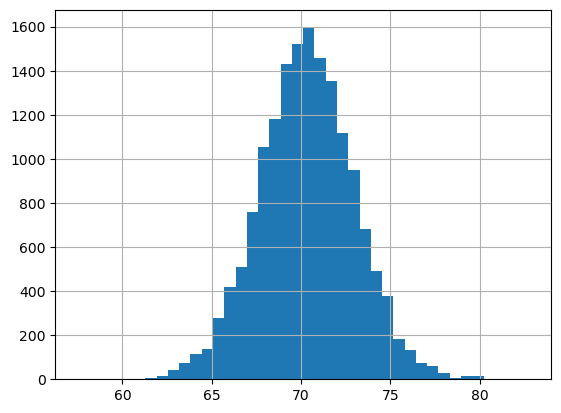

In [12]:
df['model_bat_speed'].hist(bins=40)

In [11]:
print(prior_mean+prior_std*1.25*3)
print(prior_mean-prior_std*1.25*3)

80.33623330262468
60.30147899745823


In [13]:
assert(np.isnan(swings_sqrt_values).sum() == 0)

In [ ]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list,
    "month": month_name_list
}

# pymc model
with pm.Model(coords=coords) as model_quad:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    month_idx = pm.Data("month_idx", month_idx_vals, dims=("observation_id",))
    age_data = pm.Data('age_data', age_values)
    age_sq_data = pm.Data('age_sq_data', age_sq_values)
    swings_sqrt = pm.Data('swings_sqrt', swings_sqrt_values)

    # # hyper priors for players
    mu_pop = pm.Normal("mu_pop", mu=prior_mean, sigma=prior_std*1.25)
    sigma_player = pm.Exponential("sigma_player", 1.0)
    mu_player = pm.ZeroSumNormal("mu_player", sigma=sigma_player, dims=("player",))

    sigma_month = pm.Exponential("sigma_month", 1.0)
    mu_month = pm.ZeroSumNormal("mu_month", sigma=sigma_month, dims=("month",))

    # age
    a = pm.Normal("a", mu=0, sigma=1)
    b = pm.Normal("b", mu=0, sigma=1)
    f = pm.Deterministic('f', a*age_sq_data + b*age_data)

    # expected value
    theta = mu_pop + mu_player[player_idx] + mu_month[month_idx] + f

    # sigma term
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    # likelihood
    target = pm.Normal("target", mu=theta, sigma=sigma/swings_sqrt, observed=bat_speed_target)

In [15]:
# sample
trace_quad = sample(model_quad, draws = 2000, tune = 2000, target_accept = 0.99,  path='quad_model.nc')

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

In [ ]:
az.summary(trace_quad, var_names=['mu_pop', 'sigma_player', 'a', 'b', 'sigma', 'mu_month', 'sigma_month'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_pop,70.204,0.025,70.154,70.247,0.001,0.000,1056.0,2621.0,1.01
sigma_pop,2.471,0.054,2.371,2.575,0.001,0.001,10545.0,5522.0,1.00
a,-0.224,0.012,-0.246,-0.202,0.000,0.000,2073.0,3955.0,1.00
b,-0.070,0.020,-0.108,-0.034,0.001,0.000,1377.0,2590.0,1.00
sigma,9.382,0.055,9.275,9.483,0.000,0.001,12666.0,5743.0,1.00
mu_month[Mar/Apr],-0.076,0.015,-0.103,-0.045,0.000,0.000,11074.0,5761.0,1.00
mu_month[May],0.030,0.015,0.002,0.058,0.000,0.000,14955.0,5874.0,1.00
mu_month[Jun],0.078,0.015,0.050,0.107,0.000,0.000,12684.0,5866.0,1.00
mu_month[Jul],0.050,0.017,0.018,0.082,0.000,0.000,14747.0,5530.0,1.00
mu_month[Aug],-0.019,0.016,-0.048,0.011,0.000,0.000,13767.0,6071.0,1.00


array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

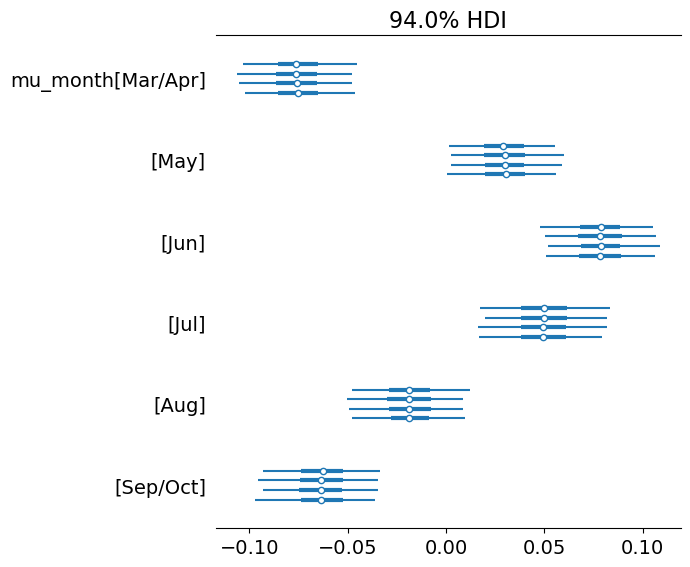

In [17]:
az.plot_forest(trace_quad, var_names='mu_month')

In [18]:
compute_log_likelihood(model_quad, trace_quad)

Output()

In [19]:
loo = az.loo(trace_quad, var_name='target')
loo

/opt/homebrew/Caskroom/miniforge/base/envs/pie/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 8000 posterior samples and 16099 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -24268.83   135.21
p_loo      960.76        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     16025   99.5%
   (0.70, 1]   (bad)         72    0.4%
   (1, Inf)   (very bad)     2    0.0%

In [20]:
spp = sample_posterior_pred(model_quad, trace_quad)

Sampling: [target]


Output()

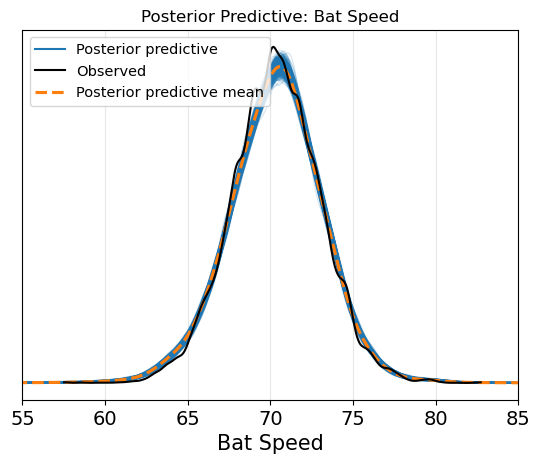

In [21]:
fig, ax0 = plt.subplots()
az.plot_ppc(spp, var_names='target', num_pp_samples=1000, random_seed=RANDOM_SEED, ax=ax0)
ax0.set_title("Posterior Predictive: Bat Speed")
ax0.set_xlabel("Bat Speed")
ax0.set_xlim(55,85)
ax0.grid(True, alpha=0.3)

<Axes: >

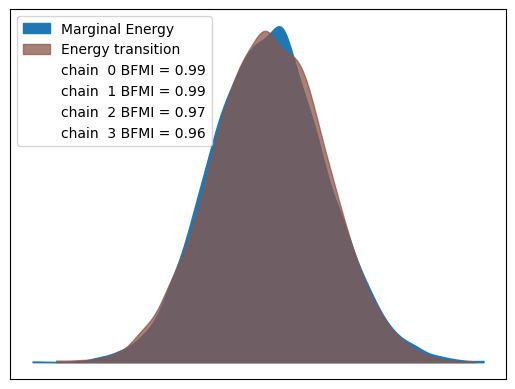

In [22]:
az.plot_energy(trace_quad)

In [23]:
target_draws = spp.posterior_predictive["target"].values
bat_speed_pred = target_draws.mean(axis=(0,1))
print(round(np.sqrt(mean_squared_error(bat_speed_target, bat_speed_pred)),4))

1.0596


In [24]:
def plot_aging_curve(trace, age_z, model_name="Model"):
    f_draws = trace.posterior["f"].values
    mu_pop_draws = trace.posterior["mu_pop"].values
    f = f_draws.reshape(-1, f_draws.shape[-1])
    mu_pop = mu_pop_draws.reshape(-1, 1)

    curves = mu_pop + f
    sort_idx = np.argsort(age_z)
    age_sorted = age_z[sort_idx]
    curves_sorted = curves[:, sort_idx]

    _, ax = plt.subplots(figsize=(8, 6))
    rng = np.random.default_rng(RANDOM_SEED)
    subset_indices = rng.choice(curves_sorted.shape[0], size=500, replace=False)
    for idx in subset_indices:
        ax.plot(age_sorted, curves_sorted[idx, :], color="darkred", alpha=0.05)

    ax.set_title(f"{model_name} Aging Curve")
    ax.set_xlabel("Age (Z-Score)")
    ax.set_ylabel("Bat Speed (mph)")
    ax.set_ylim(65, 75)
    ax.grid(True)
    plt.show()
    return curves_sorted

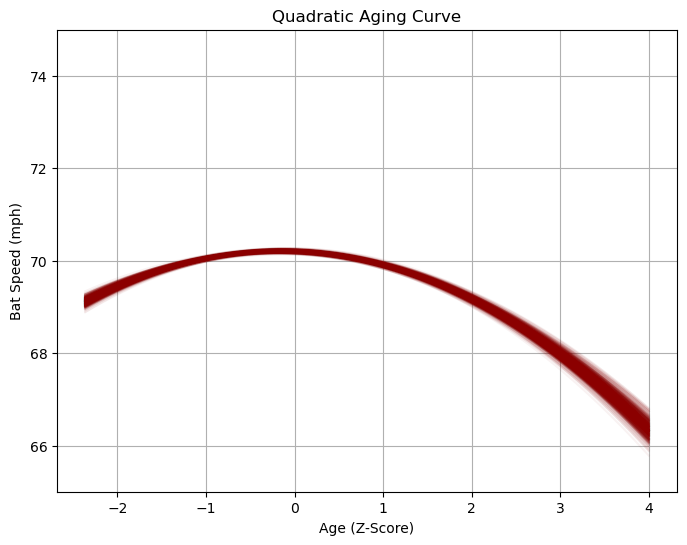

In [25]:
quad_aging_curve = plot_aging_curve(trace_quad, age_z, model_name="Quadratic")

In [29]:
# compute initial params
m_init, c_init = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[np.min(age_z), np.max(age_z)],
    lengthscale_range=[1.25, 1.75],
    cov_func="expquad",
)
print(f"m: {m_init}, c: {c_init:.2f}")

m: 7, c: 1.76


In [30]:
a_posterior_mean = trace_quad.posterior['a'].mean(dim=("chain", "draw")).values.flatten()
b_posterior_mean = trace_quad.posterior['b'].mean(dim=("chain", "draw")).values.flatten()
a_posterior_std = trace_quad.posterior['a'].std(dim=("chain", "draw")).values.flatten()
b_posterior_std = trace_quad.posterior['b'].std(dim=("chain", "draw")).values.flatten()

age_stack_data = np.column_stack((age_sq_values, age_values))

In [ ]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list,
    "month": month_name_list
}

with pm.Model(coords=coords) as model_gp_quad:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    month_idx = pm.Data("month_idx", month_idx_vals, dims=("observation_id",))
    age_stack = pm.Data('age_stack', age_stack_data)
    swings_sqrt = pm.Data('swings_sqrt', swings_sqrt_values)

    # hyper priors for players
    mu_pop = pm.Normal("mu_pop", mu=prior_mean, sigma=prior_std*1.25)
    sigma_player = pm.Exponential("sigma_player", 1.0)
    mu_player = pm.ZeroSumNormal("mu_player", sigma=sigma_player, dims=("player",))

    # month index
    sigma_month = pm.Exponential("sigma_month", 1.0)
    mu_month = pm.ZeroSumNormal("mu_month", sigma=sigma_month, dims=("month",))
    
    # mean priors
    # priors
    a = pm.Normal("a", mu=a_posterior_mean, sigma=a_posterior_std)
    b = pm.Normal("b", mu=b_posterior_mean, sigma=b_posterior_std)
    coefs = pt.stack([a, b])
    mean = pm.gp.mean.Linear(coeffs=coefs, intercept=0)
    # covariance priors
    eta = pm.HalfNormal("eta", sigma=0.5)
    ls = pm.InverseGamma("ls", alpha=11.0, beta=15.0)
    cov_func = eta**2 * pm.gp.cov.ExpQuad(input_dim=1, ls=ls, active_dims=[1])
    # HSGP
    gp = pm.gp.HSGP(m=[10], c=2, drop_first=True, mean_func=mean, cov_func=cov_func)
    f = gp.prior("f", X=age_stack)

    # expected value
    theta = mu_pop + mu_player[player_idx] + mu_month[month_idx] + f
    # lkhood
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    target = pm.Normal("target", mu=theta, sigma=sigma/swings_sqrt, observed=bat_speed_target)

Sampling: [a, b, eta, f_hsgp_coeffs, ls]


Text(0.5, 1.0, 'Prior Predictive GP Draws')

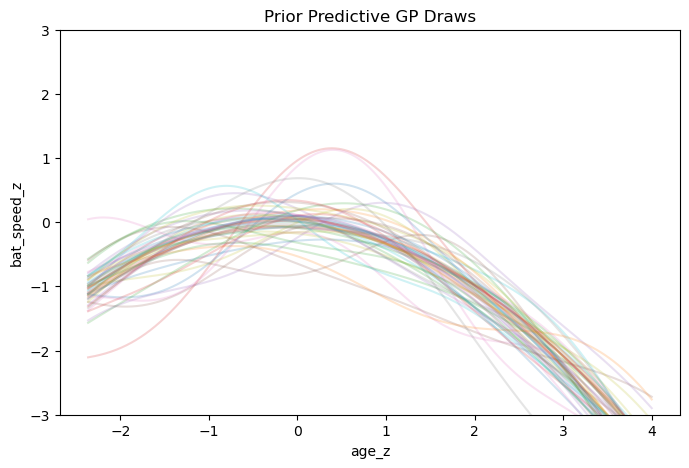

In [32]:
# prior predictve checks
samps = 50
with model_gp_quad:
    prior_samples = pm.sample_prior_predictive(samples=samps, var_names=["eta", "ls", "f"], random_seed=RANDOM_SEED)

# gp draws directly from HSGP
gp_draws = prior_samples.prior["f"].values.reshape(-1, len(age_z))
plt.figure(figsize=(8, 5))
for draw in gp_draws:
    sort_idx = np.argsort(age_z)
    plt.plot(age_z[sort_idx], draw[sort_idx], alpha=0.2)
plt.ylim(-3, 3)
plt.xlabel("age_z")
plt.ylabel("bat_speed_z")
plt.title("Prior Predictive GP Draws")

In [33]:
# sample
trace_gp_quad = sample(model_gp_quad, draws = 2000, tune = 2000, target_accept = 0.99,  path='gp_expquad_quadratic.nc')

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

In [ ]:
az.summary(trace_gp_quad, var_names=['eta', 'ls','mu_pop', 'sigma_player', 'a','b', 'mu_month', 'sigma_month'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
eta,0.620,0.248,0.152,1.053,0.005,0.003,2151.0,2424.0,1.0
ls,1.106,0.207,0.717,1.480,0.003,0.002,6927.0,6432.0,1.0
mu_pop,69.952,0.145,69.690,70.229,0.003,0.002,2772.0,4402.0,1.0
sigma_pop,2.473,0.054,2.375,2.579,0.000,0.001,11858.0,6858.0,1.0
a[0],-0.227,0.011,-0.250,-0.207,0.000,0.000,12149.0,5401.0,1.0
b[0],-0.068,0.019,-0.104,-0.033,0.000,0.000,16405.0,5561.0,1.0
mu_month[Mar/Apr],-0.076,0.015,-0.106,-0.048,0.000,0.000,17618.0,5897.0,1.0
mu_month[May],0.030,0.015,0.002,0.058,0.000,0.000,15817.0,5773.0,1.0
mu_month[Jun],0.079,0.015,0.049,0.108,0.000,0.000,16834.0,5802.0,1.0
mu_month[Jul],0.049,0.017,0.018,0.080,0.000,0.000,17635.0,6350.0,1.0


array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

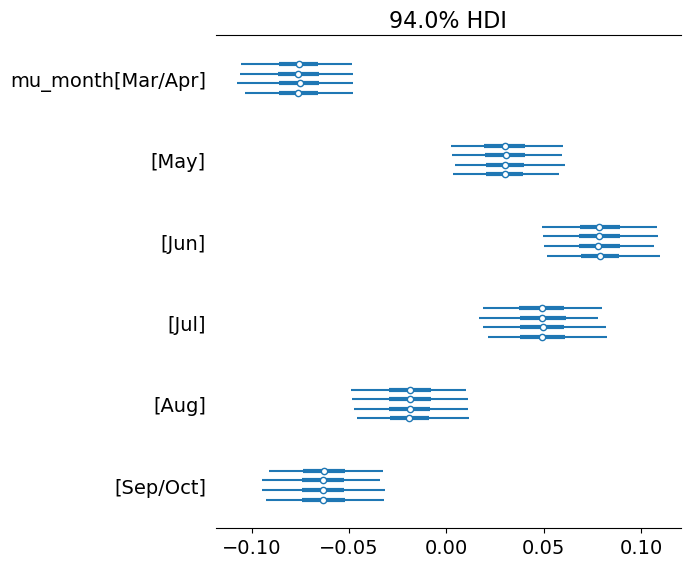

In [35]:
az.plot_forest(trace_gp_quad, var_names = 'mu_month')

In [36]:
compute_log_likelihood(model_gp_quad, trace_gp_quad)

Output()

In [37]:
loo = az.loo(trace_gp_quad, var_name='target')
loo

/opt/homebrew/Caskroom/miniforge/base/envs/pie/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 8000 posterior samples and 16099 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -24246.71   134.67
p_loo      969.03        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     16029   99.6%
   (0.70, 1]   (bad)         68    0.4%
   (1, Inf)   (very bad)     2    0.0%

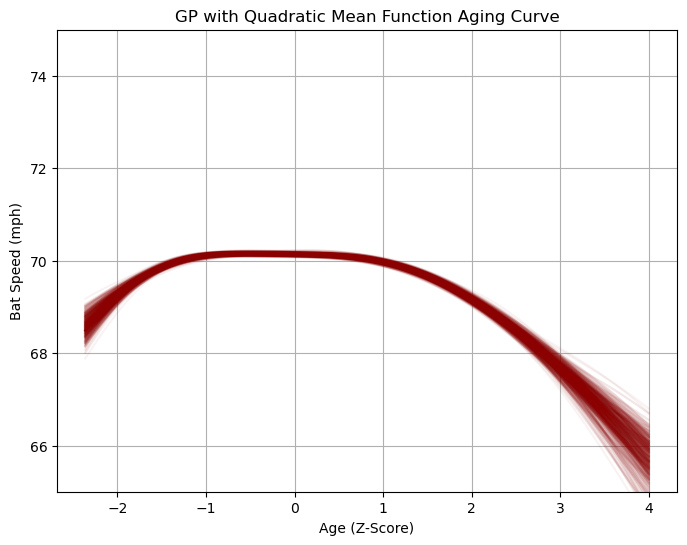

In [38]:
gp_aging_curve = plot_aging_curve(trace_gp_quad, age_z, model_name="GP with Quadratic Mean Function")

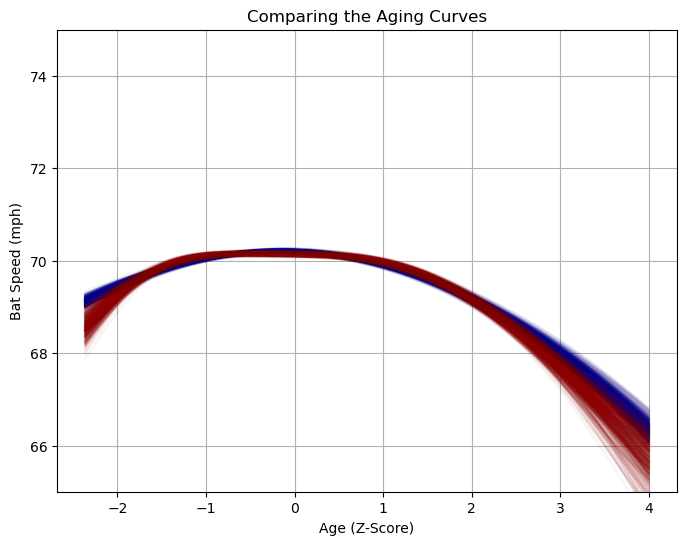

In [39]:
sort_idx = np.argsort(age_z)
age_sorted = age_z[sort_idx]
_, ax = plt.subplots(figsize=(8, 6))
rng = np.random.default_rng(RANDOM_SEED)
subset_indices = rng.choice(quad_aging_curve.shape[0], size=500, replace=False)
for idx in subset_indices:
    ax.plot(age_sorted, quad_aging_curve[idx, :], color="darkblue", alpha=0.05)
for idx in subset_indices:
    ax.plot(age_sorted, gp_aging_curve[idx, :], color="darkred", alpha=0.05)

ax.set_title(f"Comparing the Aging Curves")
ax.set_xlabel("Age (Z-Score)")
ax.set_ylabel("Bat Speed (mph)")
ax.set_ylim(65, 75)
ax.grid(True)
plt.show()

In [40]:
spp = sample_posterior_pred(model_gp_quad, trace_gp_quad)

Sampling: [target]


Output()

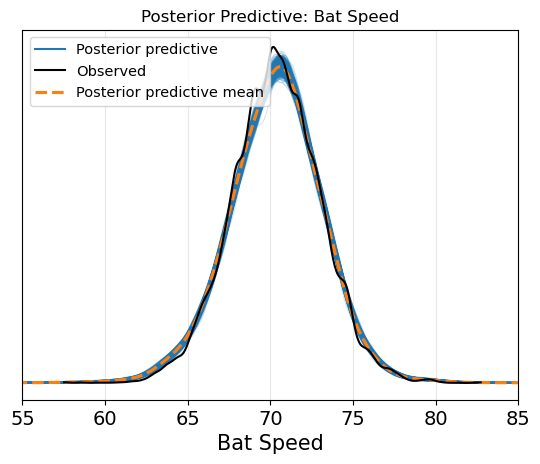

In [41]:
fig, ax0 = plt.subplots()
az.plot_ppc(spp, var_names='target', num_pp_samples=1000, random_seed=RANDOM_SEED, ax=ax0)
ax0.set_title("Posterior Predictive: Bat Speed")
ax0.set_xlabel("Bat Speed")
ax0.set_xlim(55,85)
ax0.grid(True, alpha=0.3)

In [42]:
target_draws = spp.posterior_predictive["target"].values
bat_speed_pred = target_draws.mean(axis=(0,1))
print(round(np.sqrt(mean_squared_error(bat_speed_target, bat_speed_pred)),4))

1.0593


In [63]:
# add position
pdf = df[['bam_id','player_full_id','full','position','position_hybrid']].drop_duplicates(['player_full_id']).reset_index(drop=True)
pdf["position_idx"], position_lookup = define_index(pdf, "position_hybrid", plus_one=False)
position_idx_vals = pdf['position_idx'].values.astype("int32")
position_name_list = list(position_lookup.keys())
pdf.head()

,bam_id,player_full_id,full,position,position_hybrid,position_idx
0,405395,Albert Pujols (405395),Albert Pujols,1B,CINF,0
1,408234,Miguel Cabrera (408234),Miguel Cabrera,1B,CINF,0
2,425772,Jeff Mathis (425772),Jeff Mathis,C,C,1
3,425784,René Rivera (425784),René Rivera,C,C,1
4,425877,Yadier Molina (425877),Yadier Molina,C,C,1


In [ ]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list,
    "month": month_name_list,
    "position": position_name_list
}

with pm.Model(coords=coords) as model_gp_position:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    month_idx = pm.Data("month_idx", month_idx_vals, dims=("observation_id",))
    age_stack = pm.Data('age_stack', age_stack_data)
    swings_sqrt = pm.Data('swings_sqrt', swings_sqrt_values)
    position_idx = pm.Data('position_idx', position_idx_vals, dims=('player',))

    mu_pop = pm.Normal("mu_pop", mu=prior_mean, sigma=prior_std*1.25)
    # position
    sigma_player = pm.Exponential("sigma_player", 1.0)
    sigma_pos = pm.Exponential("sigma_pos", 1.0)
    mu_pos = pm.ZeroSumNormal("mu_pos", sigma=sigma_pos, dims=("position",))
    mu_player_raw = pm.Normal("mu_player_raw", mu=0.0, sigma=1.0, dims=("player",))
    mu_player = pm.Deterministic("mu_player", mu_pos[position_idx] + mu_player_raw*sigma_player)

    # month index
    sigma_month = pm.Exponential("sigma_month", 1.0)
    mu_month = pm.ZeroSumNormal("mu_month", sigma=sigma_month, dims=("month",))
    
    # mean priors
    a = pm.Normal("a", mu=a_posterior_mean, sigma=a_posterior_std)
    b = pm.Normal("b", mu=b_posterior_mean, sigma=b_posterior_std)
    coefs = pt.stack([a, b])
    mean = pm.gp.mean.Linear(coeffs=coefs, intercept=0)
    # covariance priors
    eta = pm.HalfNormal("eta", sigma=0.5)
    ls = pm.InverseGamma("ls", alpha=11.0, beta=15.0)
    cov_func = eta**2 * pm.gp.cov.ExpQuad(input_dim=1, ls=ls, active_dims=[1])
    # HSGP
    gp = pm.gp.HSGP(m=[10], c=2, drop_first=True, mean_func=mean, cov_func=cov_func)
    f = gp.prior("f", X=age_stack)

    # expected value
    theta = mu_pop + mu_player[player_idx] + mu_month[month_idx] + f
    # lkhood
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    target = pm.Normal("target", mu=theta, sigma=sigma/swings_sqrt, observed=bat_speed_target)

In [65]:
# sample
trace_gp_position = sample(model_gp_position, draws = 2000, tune = 2000, target_accept = 0.99,  path='gp_expquad_quadratic_position.nc')

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [66]:
az.summary(trace_gp_position, var_names=['mu_pos','sigma_pos'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_pos[CINF],0.121,0.143,-0.139,0.402,0.009,0.004,242.0,542.0,1.01
mu_pos[C],-0.761,0.163,-1.074,-0.463,0.011,0.005,225.0,424.0,1.03
mu_pos[UTM],-1.074,0.135,-1.335,-0.835,0.008,0.005,266.0,492.0,1.01
mu_pos[DH],1.574,0.297,1.017,2.132,0.016,0.008,355.0,662.0,1.01
mu_pos[COF],0.140,0.155,-0.156,0.432,0.011,0.006,208.0,335.0,1.02
sigma_pos,1.203,0.484,0.459,2.068,0.008,0.009,3053.0,3259.0,1.00


array([[<Axes: title={'center': 'mu_pos'}>,
        <Axes: title={'center': 'mu_pos'}>],
       [<Axes: title={'center': 'sigma_pos'}>,
        <Axes: title={'center': 'sigma_pos'}>]], dtype=object)

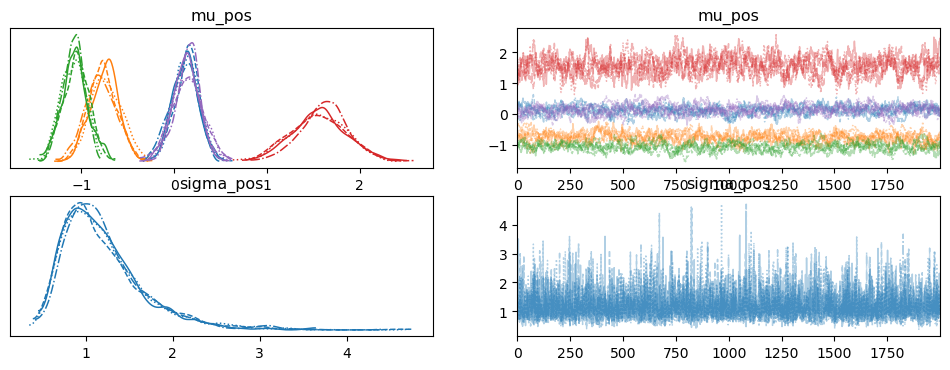

In [68]:
az.plot_trace(trace_gp_position, var_names=['mu_pos','sigma_pos'])

In [170]:
# add the auto regressive part
df.head(10)

,bam_id,year,month_name,time_index,player_full_id,full,first,last,bats,birth_date,...,swing_total,bat_speed,imputed_bat_speed,imputed_bat_speed_std,model_bat_speed,is_imputed,is_complete,age_z,player_idx,month_idx
0,405395,2021,Mar/Apr,0,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,131.0,NaN,72.313288,1.502616,72.313288,1,0,3.505337,0,0
1,405395,2021,May,1,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,107.0,NaN,72.344566,1.488726,72.344566,1,0,3.528000,0,1
2,405395,2021,Jun,2,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,92.0,NaN,72.308188,1.492607,72.308188,1,0,3.551417,0,2
3,405395,2021,Jul,3,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,106.0,NaN,72.305987,1.483824,72.305987,1,0,3.574080,0,3
4,405395,2021,Aug,4,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,54.0,NaN,72.299502,1.487205,72.299502,1,0,3.597497,0,4
5,405395,2021,Sep/Oct,5,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,39.0,NaN,72.308690,1.473018,72.308690,1,0,3.620915,0,5
6,405395,2022,Mar/Apr,6,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,55.0,NaN,72.318841,1.475831,72.318841,1,0,3.781062,0,0
7,405395,2022,May,7,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,121.0,NaN,72.347634,1.488589,72.347634,1,0,3.803724,0,1
8,405395,2022,Jun,8,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,89.0,NaN,72.412231,1.482297,72.412231,1,0,3.827142,0,2
9,405395,2022,Jul,9,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,100.0,NaN,72.499405,1.485568,72.499405,1,0,3.849804,0,3


In [171]:
df = df.reset_index(drop=False)

In [218]:
df['prior_year'] = df.groupby(['bam_id'])['year'].shift(1)
df['prev_index'] = df.groupby(['bam_id'])['index'].shift(1)
df['prev_swings'] = df.groupby(['bam_id'])['swing_total'].shift(1)
df['prior_bat_speed'] = df.groupby(['bam_id'])['model_bat_speed'].shift(1)
df[['prev_index','bam_id','year','prior_year','month_name','player_full_id','prior_bat_speed','prev_swings','swing_total']].tail(10)

,prev_index,bam_id,year,prior_year,month_name,player_full_id,prior_bat_speed,prev_swings,swing_total
16074,16073.0,808982,2025,2025.0,Sep/Oct,Jung Hoo Lee (808982),66.374359,195.0,113.0
16075,16074.0,808982,2026,2025.0,Mar/Apr,Jung Hoo Lee (808982),67.320354,113.0,192.0
16076,16075.0,808982,2026,2026.0,May,Jung Hoo Lee (808982),67.778125,192.0,153.0
16077,16076.0,808982,2026,2026.0,Jun,Jung Hoo Lee (808982),67.274510,153.0,165.0
16078,16077.0,808982,2026,2026.0,Jul,Jung Hoo Lee (808982),67.689697,165.0,28.0
16079,NaN,810938,2025,NaN,Mar/Apr,Ben Williamson (810938),NaN,NaN,99.0
16080,16079.0,810938,2025,2025.0,May,Ben Williamson (810938),68.657576,99.0,187.0
16081,16080.0,810938,2025,2025.0,Jun,Ben Williamson (810938),68.806417,187.0,134.0
16082,16081.0,810938,2025,2025.0,Jul,Ben Williamson (810938),69.335075,134.0,133.0
16083,16082.0,810938,2026,2025.0,Mar/Apr,Ben Williamson (810938),67.998496,133.0,130.0


In [173]:
df['delta_t'] = np.where(df['year']-df['prior_year']==1, 6, 1)
df['is_not_first'] = np.where(df['prior_year'].isna(),0,1)
df[['prev_index','bam_id','year','prior_year','month_name','player_full_id','prior_bat_speed']].tail(25)

,prev_index,bam_id,year,prior_year,month_name,player_full_id,prior_bat_speed
16074,16073.0,808982,2025,2025.0,Sep/Oct,Jung Hoo Lee (808982),66.374359
16075,16074.0,808982,2026,2025.0,Mar/Apr,Jung Hoo Lee (808982),67.320354
16076,16075.0,808982,2026,2026.0,May,Jung Hoo Lee (808982),67.778125
16077,16076.0,808982,2026,2026.0,Jun,Jung Hoo Lee (808982),67.274510
16078,16077.0,808982,2026,2026.0,Jul,Jung Hoo Lee (808982),67.689697
16079,NaN,810938,2025,NaN,Mar/Apr,Ben Williamson (810938),NaN
16080,16079.0,810938,2025,2025.0,May,Ben Williamson (810938),68.657576
16081,16080.0,810938,2025,2025.0,Jun,Ben Williamson (810938),68.806417
16082,16081.0,810938,2025,2025.0,Jul,Ben Williamson (810938),69.335075
16083,16082.0,810938,2026,2025.0,Mar/Apr,Ben Williamson (810938),67.998496


In [222]:
delta_t_vals = df['delta_t'].values
is_not_first_vals = df['is_not_first'].values
df['prev_index'] = df['prev_index'].fillna(0)
prev_idx_vals = df['prev_index'].values.astype("int32")
df['prior_bat_speed'] = df['prior_bat_speed'].fillna(0)
prev_bat_speed_vals = df['prior_bat_speed'].values
df['prev_swings'] = df['prev_swings'].fillna(0)
prev_sqrt_swings_vals = np.sqrt(df['prev_swings'].values)

In [240]:
mu_pop_hat = trace_gp_quad.posterior['mu_pop'].mean(dim=['chain','draw']).values 
mu_player_hat = trace_gp_quad.posterior['mu_player'].mean(dim=['chain','draw']).values 
mu_month_hat = trace_gp_quad.posterior['mu_month'].mean(dim=['chain','draw']).values 
f_hat = trace_gp_quad.posterior['f'].mean(dim=['chain','draw']).values  
baseline_hat = (
    mu_pop_hat
    + mu_player_hat[player_idx_vals]
    + mu_month_hat[month_idx_vals]
    + f_hat
)
df['baseline'] = baseline_hat

df['residual'] = df['model_bat_speed'] - df['baseline'] 
df['prev_residual'] = df.groupby('bam_id')['residual'].shift(1)
valid = df.dropna(subset=['residual', 'prev_residual'])
print(valid['residual'].corr(valid['prev_residual']))

0.45291633767955863


In [241]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list,
    "month": month_name_list
}

with pm.Model(coords=coords) as ar_model:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    age_stack = pm.Data('age_stack', age_stack_data)
    swings_sqrt = pm.Data('swings_sqrt', swings_sqrt_values)
    prev_swings_sqrt = pm.Data('prev_swings_sqrt', prev_sqrt_swings_vals, dims=("observation_id",))

    # hyper priors for players
    mu_pop = pm.Normal("mu_pop", mu=prior_mean, sigma=prior_std*1.25)
    sigma_pop = pm.Exponential("sigma_pop", 1.0)
    mu_player = pm.ZeroSumNormal("mu_player", sigma=sigma_pop, dims=("player",))

    # month index
    sigma_month = pm.Exponential("sigma_month", 1.0)
    mu_month = pm.ZeroSumNormal("mu_month", sigma=sigma_month, dims=("month",))

    delta_t_data = pm.Data('delta_t_data', delta_t_vals, dims=("observation_id",))
    is_not_first = pm.Data('is_not_first', is_not_first_vals, dims=("observation_id",))
    prev_idx = pm.Data('prev_idx', prev_idx_vals, dims=("observation_id",))
    prev_bat_speed_data = pm.Data('prev_bat_speed_data', prev_bat_speed_vals, dims=("observation_id",))

    # mean priors
    # priors
    a = pm.Normal("a", mu=a_posterior_mean, sigma=a_posterior_std)
    b = pm.Normal("b", mu=b_posterior_mean, sigma=b_posterior_std)
    coefs = pt.stack([a, b])
    mean = pm.gp.mean.Linear(coeffs=coefs, intercept=0)
    # covariance priors
    eta = pm.HalfNormal("eta", sigma=0.5)
    ls = pm.InverseGamma("ls", alpha=11.0, beta=15.0)
    cov_func = eta**2 * pm.gp.cov.ExpQuad(input_dim=1, ls=ls, active_dims=[1])
    # HSGP
    gp = pm.gp.HSGP(m=[20], c=2.5, drop_first=True, mean_func=mean, cov_func=cov_func)
    f = gp.prior("f", X=age_stack)

    # expected value
    baseline = mu_pop + mu_player[player_idx] + mu_month[month_idx] + f

    rho = pm.Beta("rho", alpha=5.0, beta=15.0)
    ar_weight = rho ** delta_t_data
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    tau = pm.HalfNormal("tau", sigma=1.0)
    prev_obs_precision = prev_swings_sqrt**2 / sigma**2
    reliability = prev_obs_precision / (prev_obs_precision + 1.0/tau**2)

    prev_residual = prev_bat_speed_data - baseline[prev_idx]
    theta = baseline + (is_not_first * ar_weight * reliability * prev_residual)
    
    target = pm.Normal("target", mu=theta, sigma=sigma/swings_sqrt, observed=bat_speed_target)

Sampling: [a, b, eta, f_hsgp_coeffs, ls]


Text(0.5, 1.0, 'Prior Predictive GP Draws')

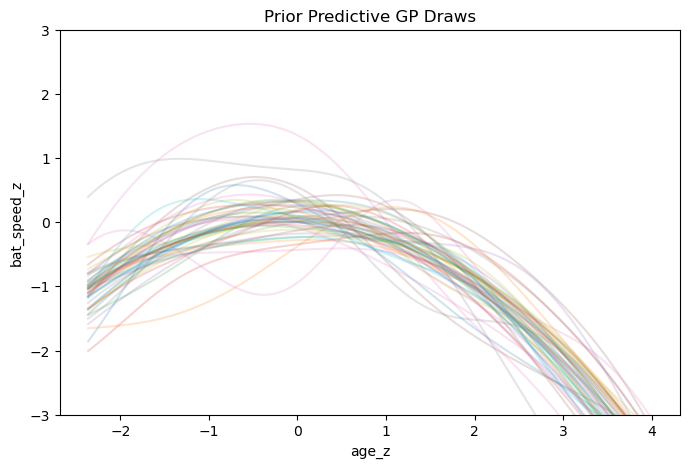

In [242]:
# prior predictve checks
samps = 50
with ar_model:
    prior_samples = pm.sample_prior_predictive(samples=samps, var_names=["eta", "ls", "f"], random_seed=RANDOM_SEED)

# gp draws directly from HSGP
gp_draws = prior_samples.prior["f"].values.reshape(-1, len(age_z))
plt.figure(figsize=(8, 5))
for draw in gp_draws:
    sort_idx = np.argsort(age_z)
    plt.plot(age_z[sort_idx], draw[sort_idx], alpha=0.2)
plt.ylim(-3, 3)
plt.xlabel("age_z")
plt.ylabel("bat_speed_z")
plt.title("Prior Predictive GP Draws")

In [243]:
# sample
trace_ar = sample(ar_model, draws = 2000, tune = 2000, target_accept = 0.99,  path='gp_expquad_ar.nc')

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


In [244]:
az.summary(trace_ar, var_names=['eta', 'ls', 'mu_pop', 'sigma_pop', 'rho', 'a','b', 'mu_month', 'sigma_month', 'tau'], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
eta,0.133,0.128,0.000,0.381,0.002,0.003,2668.0,3989.0,1.0
ls,1.612,0.592,0.717,2.776,0.007,0.010,8691.0,6005.0,1.0
mu_pop,70.191,0.070,70.042,70.329,0.001,0.002,5098.0,4494.0,1.0
sigma_pop,2.412,0.054,2.307,2.517,0.000,0.001,14449.0,6763.0,1.0
rho,0.889,0.005,0.878,0.900,0.000,0.000,7892.0,7033.0,1.0
a[0],-0.223,0.011,-0.243,-0.202,0.000,0.000,11074.0,6334.0,1.0
b[0],-0.074,0.018,-0.110,-0.039,0.000,0.000,10878.0,6290.0,1.0
mu_month[Mar/Apr],-0.065,0.011,-0.087,-0.043,0.000,0.000,13516.0,6612.0,1.0
mu_month[May],0.013,0.011,-0.008,0.033,0.000,0.000,11251.0,7067.0,1.0
mu_month[Jun],0.059,0.011,0.037,0.080,0.000,0.000,12353.0,6894.0,1.0


<Axes: xlabel='rho', ylabel='ls'>

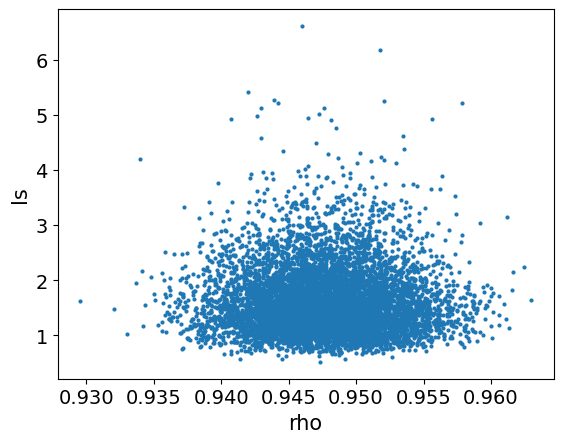

In [233]:
az.plot_pair(trace_ar, var_names=["rho", "ls"], kind="scatter", divergences=True)

In [227]:
compute_log_likelihood(ar_model, trace_ar)

Output()

In [213]:
loo = az.loo(trace_ar, var_name='target')
loo

/opt/homebrew/Caskroom/miniforge/base/envs/pie/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 8000 posterior samples and 16099 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -21322.94   157.17
p_loo     1190.78        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     15823   98.3%
   (0.70, 1]   (bad)        259    1.6%
   (1, Inf)   (very bad)    17    0.1%

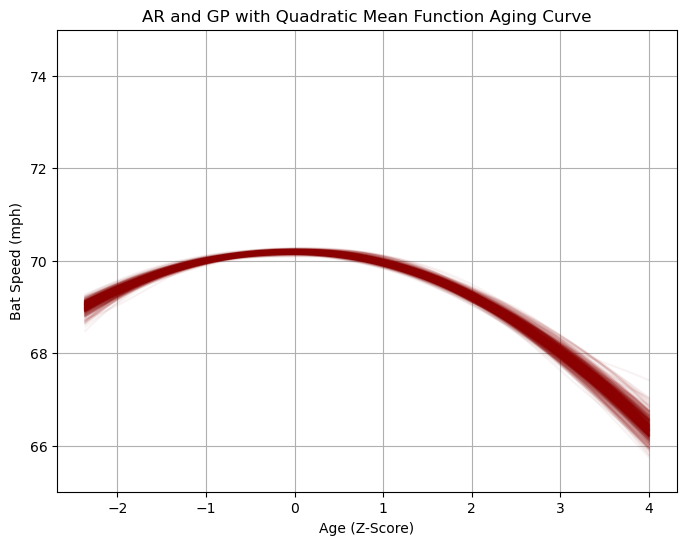

In [228]:
ar_aging_curve = plot_aging_curve(trace_ar, age_z, model_name="AR and GP with Quadratic Mean Function")

In [245]:
spp = sample_posterior_pred(model_gp_quad, trace_gp_quad)

Sampling: [target]


Output()

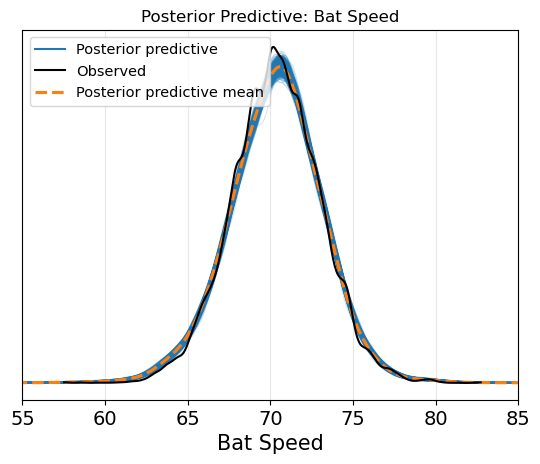

In [230]:
fig, ax0 = plt.subplots()
az.plot_ppc(spp, var_names='target', num_pp_samples=1000, random_seed=RANDOM_SEED, ax=ax0)
ax0.set_title("Posterior Predictive: Bat Speed")
ax0.set_xlabel("Bat Speed")
ax0.set_xlim(55,85)
ax0.grid(True, alpha=0.3)

In [246]:
target_draws = spp.posterior_predictive["target"].values
bat_speed_pred = target_draws.mean(axis=(0,1))
print(round(np.sqrt(mean_squared_error(bat_speed_target, bat_speed_pred)),4))


1.0593
